# A03 - Baseline Deep Learning (MLP)

Este notebook documenta a implementacao de um baseline de Deep Learning com rede neural densa (MLP) para classificacao binaria de prospectividade mineral. A proposta e servir como referencia tecnica para as proximas etapas do projeto, em especial para a comparacao com modelos convolucionais. A escrita desta entrega foi organizada para mostrar nao apenas o que foi feito, mas tambem por que cada escolha metodologica foi adotada e quais limites ainda permanecem.


## Criterios Cobertos

A estrutura do notebook foi montada para responder diretamente aos cinco itens da rubrica. Primeiro, apresentamos a preparacao dos dados com controle de vazamento por grupo e tratamento de dimensionalidade. Em seguida, descrevemos a implementacao do MLP e o processo de treinamento com regularizacao. Depois, registramos a avaliacao quantitativa com metricas classicas de classificacao e visualizacoes de desempenho. Por fim, incluimos uma analise critica textual conectando os resultados ao contexto geologico discutido no A1 e aos proximos passos do projeto.


### Entregaveis e saidas esperadas

A pasta do artefato contem dois entregaveis principais: o notebook `a03_mlp_baseline.ipynb` e o arquivo `README.md`. Durante a execucao, o notebook salva automaticamente os artefatos experimentais em `outputs/a03_mlp_baseline`, incluindo modelo treinado, metricas em JSON, curvas de loss e accuracy, matriz de confusao, curva ROC, tempos de treino e inferencia, alem da analise de permutation importance. Essa persistencia foi mantida para que os resultados possam ser auditados e comparados com as proximas sprints.


### Reuso de codigo do projeto (`src`)

Uma decisao importante deste notebook foi reaproveitar funcoes da base `src` para manter consistencia com o restante do repositorio. O carregamento e rotulagem dos dados foi feito com `prepare_dataset_with_groups`, a normalizacao com `standardize_bands`, a reducao de dimensionalidade com `apply_pca`, a definicao de ativacoes com `select_mlp_activations` e o calculo padronizado de metricas com `classification_metrics_extended`. Essa escolha reduz risco de divergencia entre artefatos e facilita manutencao. A unica etapa implementada localmente foi a agregacao `pixel_*` para medias por banda, porque ela depende da forma especifica como os chips foram tabularizados no A1.


### Reproducao do experimento

A reproducao foi planejada para ser simples: abrir este notebook, executar as celulas em ordem e verificar os arquivos gerados em `outputs/a03_mlp_baseline`. Mantivemos controle de semente (`SEED = 42`) para `random`, `numpy` e `tensorflow`, o que melhora a estabilidade da comparacao entre execucoes. Apesar de nao eliminar toda variabilidade inerente ao treino estocastico, essa configuracao permite uma linha de base suficientemente confiavel para analise academica.


### Limitacoes do baseline

Mesmo com resultados consistentes, este baseline tem limitacoes estruturais. A principal e que a representacao por medias de banda comprime fortemente o sinal espacial dos chips, descartando textura e padroes locais que podem ser relevantes para o problema geologico. Alem disso, o volume de amostras ainda e restrito para o tamanho do espaco de hipoteses de modelos neurais. Portanto, os numeros obtidos aqui devem ser tratados como referencia inicial para comparacao, e nao como teto de desempenho do projeto.


In [4]:
from pathlib import Path
import sys

repo_root = Path().resolve()
while repo_root != repo_root.parent and not (repo_root / "src").exists():
    repo_root = repo_root.parent

if not (repo_root / "src").exists():
    raise RuntimeError("Nao encontrei a pasta 'src' acima do diretorio atual.")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print(f"Repositorio: {repo_root}")


Repositorio: /home/inteli/Documentos/3ANO/PROJETO/g01


### Instalacao de dependencias (se necessario)

Se ocorrer erro de `ModuleNotFoundError` (ex.: `tensorflow`), execute a celula abaixo e depois **reinicie o kernel**.


In [ ]:
import importlib.util
import subprocess
import sys


def ensure_package(import_name: str, pip_name: str | None = None):
    if importlib.util.find_spec(import_name) is None:
        pkg = pip_name or import_name
        print(f"Instalando {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
    else:
        print(f"{import_name} ja esta instalado.")


# Dependencias centrais deste notebook
ensure_package("tensorflow", "tensorflow")
ensure_package("numpy", "numpy")
ensure_package("pandas", "pandas")
ensure_package("sklearn", "scikit-learn")
ensure_package("matplotlib", "matplotlib")
ensure_package("seaborn", "seaborn")

print("Instalacao/verificacao concluida. Se algo foi instalado agora, reinicie o kernel.")


In [5]:
import json
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from src.utils.prepare_dataset import prepare_dataset_with_groups
from src.preprocessamento.pixel_preprocessing import standardize_bands, apply_pca
from src.models.mlp_activations import select_mlp_activations
from src.utils.metrics import classification_metrics_extended
from src.analise_visual.graficos import plot_confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

sns.set(style="whitegrid")


2026-02-26 22:35:38.457341: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-26 22:35:38.465791: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-26 22:35:38.861187: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-26 22:35:40.844293: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

## 1) Preparacao dos dados para Deep Learning

A preparacao dos dados foi orientada pelos riscos identificados no A1. O dataset de entrada vem de chips ASTER de `128 x 128` com 9 bandas, o que resulta em `9 x 128 x 128 = 147456` features `pixel_*` por amostra apos flatten. Esse formato e util para rastreabilidade e para baselines tabulares, mas tende a ser instavel em cenario de baixa amostragem quando usado diretamente em redes densas.

Por isso, adotamos uma estrategia de reducao controlada: primeiro garantimos split por `image_id` para evitar vazamento entre amostras correlacionadas da mesma imagem; depois agregamos cada chip em medias por banda para reduzir dimensionalidade sem perder completamente o conteudo espectral; em seguida aplicamos normalizacao e PCA com 95% de variancia explicada. O objetivo nao foi maximizar complexidade, mas construir uma entrada estatisticamente mais robusta para um baseline comparavel.


### Etapa 1.1 - Carregamento e verificacao inicial (antes da execucao)

Nesta celula vamos carregar os arquivos de entrada, aplicar o contrato de rotulagem vindo do A1 e checar rapidamente se o dataset esta consistente para modelagem. O objetivo desta verificacao inicial e garantir que a quantidade de amostras, o balanceamento de classes e a quantidade de features `pixel_*` fazem sentido antes de qualquer split.

Pontos esperados no output:
- tamanho do dataframe com labels validos;
- distribuicao basica das classes;
- contagem de features e de `image_id` unicos.


In [6]:
DATASET_PATH = repo_root / "data" / "pixels_dataset.csv"
CODES_PATH = repo_root / "data" / "extracted_codes.json"
OUTPUT_DIR = repo_root / "outputs" / "a03_mlp_baseline"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

X_raw, y_raw, groups, df_all, feature_cols = prepare_dataset_with_groups(
    dataset_path=str(DATASET_PATH),
    extracted_codes_path=str(CODES_PATH),
    drop_invalid=True,
)

pixel_feature_cols = [c for c in feature_cols if c.startswith("pixel_")]

print("Dataset preparado:", df_all.shape)
print("Classes:", df_all["label"].value_counts().to_dict())
print("Total de features pixel:", len(pixel_feature_cols))
print("Total de image_id unicos:", df_all["image_id"].nunique())


Dataset preparado: (295, 147466)
Classes: {0: 179, 1: 116}
Total de features pixel: 147456
Total de image_id unicos: 295


### Etapa 1.2 - Split por grupo (antes da execucao)

Aqui o foco e evitar leakage. Em vez de dividir amostras aleatoriamente, o split e feito por `image_id`, preservando separacao entre treino, validacao e teste quando varias amostras pertencem a mesma imagem original. Esse cuidado e essencial para que as metricas representem generalizacao real, e nao memorizacao de padroes da mesma cena.


In [7]:
# Split estratificado por image_id (sem vazamento)
image_level = df_all[["image_id", "label"]].drop_duplicates()

train_val_ids, test_ids = train_test_split(
    image_level["image_id"],
    test_size=0.20,
    random_state=SEED,
    stratify=image_level["label"],
)

train_val_level = image_level[image_level["image_id"].isin(train_val_ids)]

train_ids, val_ids = train_test_split(
    train_val_level["image_id"],
    test_size=0.25,  # 0.25 de 80% = 20% do total
    random_state=SEED,
    stratify=train_val_level["label"],
)

df_train = df_all[df_all["image_id"].isin(train_ids)].copy()
df_val = df_all[df_all["image_id"].isin(val_ids)].copy()
df_test = df_all[df_all["image_id"].isin(test_ids)].copy()

print("Shape treino:", df_train.shape)
print("Shape validacao:", df_val.shape)
print("Shape teste:", df_test.shape)

for nome, df_split in [("treino", df_train), ("validacao", df_val), ("teste", df_test)]:
    print(nome, df_split["label"].value_counts().to_dict())


Shape treino: (177, 147466)
Shape validacao: (59, 147466)
Shape teste: (59, 147466)
treino {0: 107, 1: 70}
validacao {0: 36, 1: 23}
teste {0: 36, 1: 23}


### Etapa 1.3 - Reducao da representacao espectral (antes da execucao)

Esta etapa transforma a representacao de alta dimensionalidade em uma versao mais estavel para baseline. Cada amostra sai de 147456 features (`9 x 128 x 128`) para medias por banda. A decisao nao elimina o valor geologico do dado, mas reduz o risco de sobreajuste extremo no cenario atual de amostragem.


In [8]:
# Conversao de 147456 pixels (9 bandas x 128x128) para media por banda

def compute_band_means(df, pixel_cols, n_bands=9):
    n_pixels = len(pixel_cols)
    if n_pixels % n_bands != 0:
        raise ValueError(f"Numero de pixel_cols ({n_pixels}) nao divisivel por {n_bands} bandas.")

    pixels_per_band = n_pixels // n_bands
    side = int(np.sqrt(pixels_per_band))
    if side * side != pixels_per_band:
        raise ValueError("Pixels por banda nao formam chip quadrado.")

    X = df[pixel_cols].values.reshape(len(df), n_bands, pixels_per_band)
    band_means = X.mean(axis=2)

    band_cols = [f"B{i+1:02d}" for i in range(n_bands)]
    out = pd.DataFrame(band_means, columns=band_cols, index=df.index)
    out["label"] = df["label"].astype(int).values
    out["image_id"] = df["image_id"].values
    return out


df_train_spec = compute_band_means(df_train, pixel_feature_cols, n_bands=9)
df_val_spec = compute_band_means(df_val, pixel_feature_cols, n_bands=9)
df_test_spec = compute_band_means(df_test, pixel_feature_cols, n_bands=9)

band_cols = [c for c in df_train_spec.columns if c.startswith("B")]
print("Bandas finais:", band_cols)
print("Amostras treino/val/test:", len(df_train_spec), len(df_val_spec), len(df_test_spec))


Bandas finais: ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09']
Amostras treino/val/test: 177 59 59


In [9]:
# Normalizacao usando funcao utilitaria de src

df_train_std, scaler = standardize_bands(df_train_spec[band_cols].copy(), band_cols)
X_train_std = df_train_std[band_cols].values
X_val_std = scaler.transform(df_val_spec[band_cols])
X_test_std = scaler.transform(df_test_spec[band_cols])

y_train = df_train_spec["label"].values.astype(int)
y_val = df_val_spec["label"].values.astype(int)
y_test = df_test_spec["label"].values.astype(int)

print("Shape padronizado treino:", X_train_std.shape)


Shape padronizado treino: (177, 9)


In [10]:
# PCA (95% variancia) usando funcao utilitaria de src

X_train_std_df = pd.DataFrame(X_train_std, columns=band_cols)
df_train_pca, pca_model = apply_pca(
    df_pixels_standardized=X_train_std_df,
    band_cols=band_cols,
    variance_threshold=0.95,
)

X_train_pca = df_train_pca.values
X_val_pca = pca_model.transform(X_val_std)
X_test_pca = pca_model.transform(X_test_std)

explained = pca_model.explained_variance_ratio_
print("Componentes PCA:", pca_model.n_components_)
print("Variancia explicada por componente:", np.round(explained, 4))
print("Variancia cumulativa:", np.round(explained.cumsum(), 4))


Componentes PCA: 2
Variancia explicada por componente: [0.9207 0.0488]
Variancia cumulativa: [0.9207 0.9694]


/home/inteli/Documentos/3ANO/PROJETO/g01/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/home/inteli/Documentos/3ANO/PROJETO/g01/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


### Etapa 1.4 - Leitura dos outputs de preparacao (apos execucao)

A leitura desta etapa deve ser feita em tres niveis. O primeiro nivel e estrutural: os tamanhos de treino, validacao e teste precisam estar coerentes com o split por grupo, sem sinais de desbalanceamento extremo entre particoes. O segundo nivel e estatistico: a normalizacao deve produzir variaveis em escala comparavel, evitando que uma banda domine o gradiente apenas por amplitude numerica. O terceiro nivel e de compressao de informacao: o numero de componentes do PCA e a variancia cumulativa explicada indicam se a representacao agregada ainda preserva sinal suficiente para classificacao.

Quando poucas componentes atingem alta variancia explicada, isso sugere redundancia entre bandas na forma agregada, o que reforca a opcao por um baseline denso mais simples nesta sprint. Se, por outro lado, o PCA exigir muitas componentes para manter 95% da variancia, isso sugere estrutura mais complexa e aumenta a chance de instabilidade na generalizacao, exigindo cautela adicional na interpretacao das metricas finais.


### Ponte teorica com o A1 (hipoteses e expectativas testaveis)

No A1, a analise exploratoria sugeriu que assinaturas espectrais associadas a alteracao mineral, especialmente no intervalo SWIR, carregam informacao discriminativa para separar amostras positivas e negativas. Este notebook usa essas observacoes como referencia teorica: esperamos desempenho superior ao acaso nas metricas de classificacao, padrao de erro coerente na matriz de confusao e importance ranking plausivel do ponto de vista geologico.

Essa ponte entre EDA e modelagem e importante porque evita uma leitura puramente numerica. Em vez de tratar ROC-AUC ou F1 como fim em si mesmos, interpretamos os outputs como testes empiricos de hipoteses levantadas anteriormente.


## 2) Implementacao da rede neural densa (MLP)

A arquitetura escolhida e propositalmente simples: duas camadas densas ocultas com ReLU, regularizacao L2 e dropout, seguidas de uma saida sigmoide para classificacao binaria. Essa configuracao busca equilibrio entre capacidade de modelagem nao linear e controle de sobreajuste, dado que trabalhamos com quantidade limitada de amostras. Em termos de engenharia experimental, a escolha tambem facilita reproducao e comparacao direta com modelos futuros mais complexos.


### Etapa 2.1 - Configuracao e construcao do modelo (antes da execucao)

Nas proximas celulas vamos definir ativacoes, construir a arquitetura densa e compilar o modelo. A ideia aqui e manter um baseline interpretable e suficientemente regularizado para servir como referencia de comparacao com arquiteturas convolucionais nas proximas entregas.


In [11]:
TASK_TYPE = "classification"
N_CLASSES = 2

activation_cfg = select_mlp_activations(task_type=TASK_TYPE, n_classes=N_CLASSES)
hidden_activation = activation_cfg["hidden_activation"]
output_activation = activation_cfg["output_activation"]

print("Ativacoes selecionadas:")
print(json.dumps(activation_cfg, indent=2, ensure_ascii=False))


Ativacoes selecionadas:
{
  "hidden_activation": "relu",
  "hidden_justification": "ReLU nas camadas ocultas acelera o treinamento e reduz saturacao de gradiente em comparacao com Sigmoid.",
  "output_activation": "sigmoid",
  "output_justification": "Sigmoid na saida e adequada para classificacao binaria, produzindo probabilidade no intervalo [0, 1]."
}


### Hiperparametros

Os hiperparametros abaixo foram definidos com foco em estabilidade de treinamento e generalizacao. Em vez de perseguir ajuste agressivo, priorizamos uma configuracao conservadora para baseline, de forma que o ganho observado em arquiteturas futuras possa ser atribuido ao modelo e nao a tuning excessivo neste estagio.

| Hiperparametro | Valor |
|---|---|
| Learning rate | 0.001 |
| Otimizador | Adam |
| Batch size | 32 |
| Epocas maximas | 100 |
| Hidden units | 64, 32 |
| Hidden activation | ReLU |
| Output activation | Sigmoid |
| Loss | Binary Crossentropy |
| Dropout | 0.3 |
| L2 | 1e-3 |


In [12]:
INPUT_SHAPE = (X_train_pca.shape[1],)

def build_mlp(input_shape, hidden_activation="relu", output_activation="sigmoid"):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Dense(64, activation=hidden_activation, kernel_regularizer=regularizers.l2(1e-3)),
        layers.Dropout(0.3),
        layers.Dense(32, activation=hidden_activation, kernel_regularizer=regularizers.l2(1e-3)),
        layers.Dropout(0.3),
        layers.Dense(1, activation=output_activation),
    ])
    return model

model = build_mlp(INPUT_SHAPE, hidden_activation, output_activation)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc_roc"),
    ],
)

model.summary()


2026-02-26 22:37:06.805547: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,305 (9.00 KB)

 Trainable params: 2,305 (9.00 KB)

 Non-trainable params: 0 (0.00 B)

## 3) Treinamento e validacao

O treinamento foi conduzido com conjunto de validacao explicito e mecanismos de regularizacao para conter sobreajuste. O dropout atua como ruido estruturado durante o treino, a penalizacao L2 reduz dependencia de pesos extremos, o early stopping evita continuar aprendendo apos degradacao de validacao e o ReduceLROnPlateau ajusta dinamicamente a taxa de aprendizado quando o progresso estagna. Em conjunto, essas tecnicas tornam o baseline mais defensavel para comparacao entre sprints.


### Etapa 3.1 - Treinamento supervisionado (antes da execucao)

Esta celula executa o treinamento com validacao e callbacks de controle de overfitting. O ponto mais importante no output e observar se o treinamento converge sem degradar validacao por muitas epocas, alem do tempo total de treino para discutir viabilidade computacional.


In [13]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=6, min_lr=1e-5),
]

start_train = time.perf_counter()
history = model.fit(
    X_train_pca,
    y_train,
    validation_data=(X_val_pca, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=0,
)
train_time_s = time.perf_counter() - start_train

print(f"Epocas executadas: {len(history.history['loss'])}")
print(f"Tempo de treino (s): {train_time_s:.4f}")


Epocas executadas: 50
Tempo de treino (s): 5.3858


### Etapa 3.2 - Leitura do output de treinamento (apos execucao)

Nesta etapa, nao basta observar se o treinamento terminou; e preciso interpretar como ele terminou. O numero de epocas efetivamente executadas mostra o comportamento do early stopping e ajuda a inferir se o modelo encontrou um ponto de estabilizacao ou se parou por oscilacao de validacao. As curvas de loss e accuracy devem ser avaliadas em conjunto: diferenca pequena e estavel entre treino e validacao indica regime mais saudavel; abertura crescente entre curvas indica sobreajuste progressivo.

O tempo total de treino tambem e um output relevante, porque baseline bom para comparacao precisa ser reproduzivel e viavel computacionalmente. Se o modelo exige muito tempo para pouco ganho de validacao, isso sinaliza baixa eficiencia da representacao atual e fortalece a migracao para arquiteturas espaciais mais adequadas ao problema.


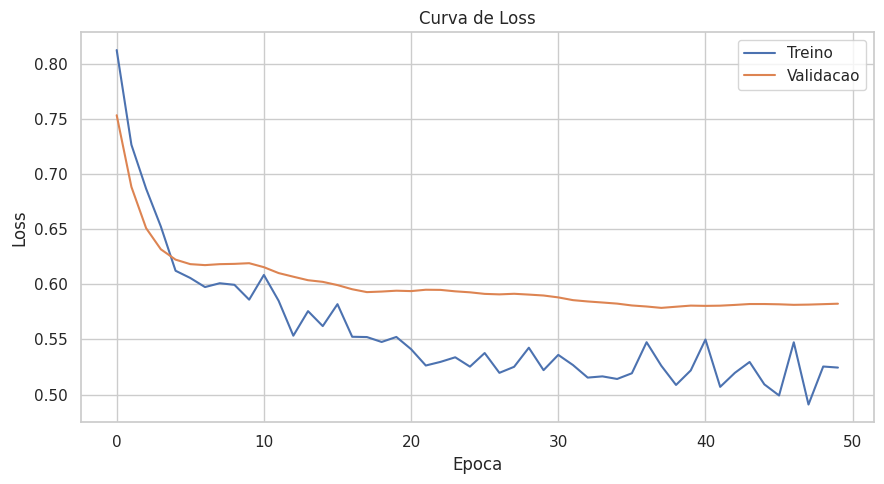

In [14]:
# Curvas de loss
plt.figure(figsize=(9, 5))
plt.plot(history.history["loss"], label="Treino")
plt.plot(history.history["val_loss"], label="Validacao")
plt.title("Curva de Loss")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()


### Análise do gráfico de Loss (após execução)

A curva de loss mostra convergência rápida nas primeiras épocas, seguida de estabilização mais lenta. O loss de treino cai de forma consistente até a faixa de aproximadamente 0,50-0,55, enquanto o loss de validação se estabiliza por volta de 0,58. Isso indica que o modelo aprendeu padrão útil, mas com um gap persistente entre treino e validação, compatível com sobreajuste leve.

Esse comportamento é coerente com o contexto deste baseline: mesmo com regularização, a combinação de baixa amostragem e compressão da entrada (médias por banda + PCA) limita o quanto a validação consegue acompanhar o treino. Em termos práticos, o gráfico sugere que o modelo é funcional como referência, mas ainda distante de capturar toda a complexidade do problema.


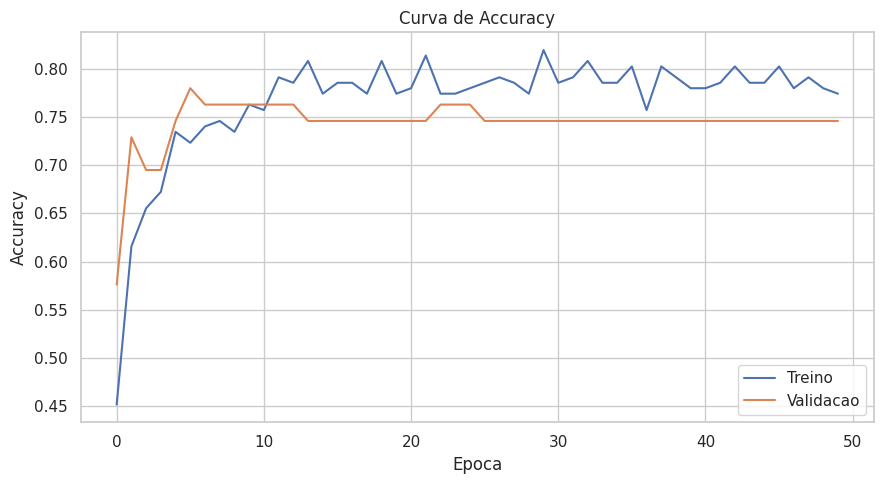

In [15]:
# Curvas de accuracy
plt.figure(figsize=(9, 5))
plt.plot(history.history["accuracy"], label="Treino")
plt.plot(history.history["val_accuracy"], label="Validacao")
plt.title("Curva de Accuracy")
plt.xlabel("Epoca")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


### Análise do gráfico de Accuracy (após execução)

A accuracy de treino sobe até valores próximos de 0,80, enquanto a validação permanece em patamar inferior, estabilizando em torno de 0,74-0,76 após as primeiras épocas. A diferença entre curvas confirma o sinal já observado no loss: há aprendizado consistente, porém com ganho de generalização mais modesto que o ganho em treino.

Do ponto de vista metodológico, o resultado é aceitável para baseline, porque não há colapso de validação nem comportamento errático. Ainda assim, o platô de validação indica limite da representação atual, reforçando a necessidade de modelos que preservem estrutura espacial na próxima etapa.


## 4) Avaliacao quantitativa de desempenho

A avaliacao foi estruturada para refletir o criterio definido no A1 de nao depender apenas de acuracia. Por isso, reportamos accuracy, precision, recall, F1 e ROC-AUC, alem da matriz de confusao e da curva ROC. Esse conjunto permite observar o desempenho global e, ao mesmo tempo, inspecionar o tipo de erro que o modelo comete, o que e essencial em um problema de priorizacao de alvos.


### Etapa 4.1 - Avaliacao do modelo no teste (antes da execucao)

Aqui consolidamos as metricas finais no conjunto de teste e registramos tempos de inferencia. Este bloco e o nucleo da comparacao futura com CNN, porque define o desempenho de referencia do baseline MLP no mesmo protocolo de split.


In [17]:
# Avaliacao no conjunto de teste
raw_eval = model.evaluate(X_test_pca, y_test, verbose=0)
keras_metrics = dict(zip(model.metrics_names, raw_eval))

start_inf = time.perf_counter()
y_prob = model.predict(X_test_pca, verbose=0).ravel()
infer_time_s = time.perf_counter() - start_inf

y_pred = (y_prob >= 0.5).astype(int)

sk_metrics = classification_metrics_extended(y_test, y_pred, y_prob)
sk_metrics["roc_auc"] = float(roc_auc_score(y_test, y_prob))

results_all = {
    "keras_metrics": {k: float(v) for k, v in keras_metrics.items()},
    "sklearn_metrics": {k: (None if v is None else float(v)) for k, v in sk_metrics.items()},
    "train_time_s": float(train_time_s),
    "inference_time_s": float(infer_time_s),
    "inference_ms_per_sample": float((infer_time_s / len(X_test_pca)) * 1000),
    "n_test_samples": int(len(X_test_pca)),
    "n_pca_components": int(pca_model.n_components_),
}

print(json.dumps(results_all, indent=2))


{
  "keras_metrics": {
    "loss": 0.5029383301734924,
    "compile_metrics": 0.7966101765632629
  },
  "sklearn_metrics": {
    "accuracy": 0.7966101694915254,
    "precision": 0.7391304347826086,
    "recall": 0.7391304347826086,
    "f1": 0.7391304347826086,
    "balanced_accuracy": 0.786231884057971,
    "roc_auc": 0.8574879227053142,
    "pr_auc": 0.8221458440257736
  },
  "train_time_s": 5.385841889998119,
  "inference_time_s": 0.09938350700394949,
  "inference_ms_per_sample": 1.6844662204059235,
  "n_test_samples": 59,
  "n_pca_components": 2
}


### Etapa 4.2 - Leitura do output de avaliacao (apos execucao)

O bloco `results_all` deve ser interpretado como um conjunto integrado de evidencias, e nao como ranking isolado de numeros. Accuracy resume desempenho global, mas precision e recall mostram o tipo de erro que o modelo privilegia. O F1 sintetiza esse equilibrio, enquanto ROC-AUC informa capacidade de separacao entre classes em diferentes limiares. Em paralelo, a matriz de confusao traduz as metricas para contagens concretas de TP, TN, FP e FN.

Para este projeto, a leitura operacional e central: FN alto implica risco de deixar passar areas potencialmente relevantes; FP alto implica custo de priorizar alvos menos promissores. Por isso, a qualidade da avaliacao depende de discutir explicitamente esse trade-off. Uma avaliacao madura nao busca apenas “metricas altas”, mas um perfil de erro coerente com o objetivo de triagem geologica da sprint.


In [18]:
cm = confusion_matrix(y_test, y_pred)
print("Matriz de confusao:")
print(cm)

print("\nRelatorio de classificacao:")
print(classification_report(y_test, y_pred, target_names=["Negativo", "Positivo"], digits=4))


Matriz de confusao:
[[30  6]
 [ 6 17]]

Relatorio de classificacao:
              precision    recall  f1-score   support

    Negativo     0.8333    0.8333    0.8333        36
    Positivo     0.7391    0.7391    0.7391        23

    accuracy                         0.7966        59
   macro avg     0.7862    0.7862    0.7862        59
weighted avg     0.7966    0.7966    0.7966        59



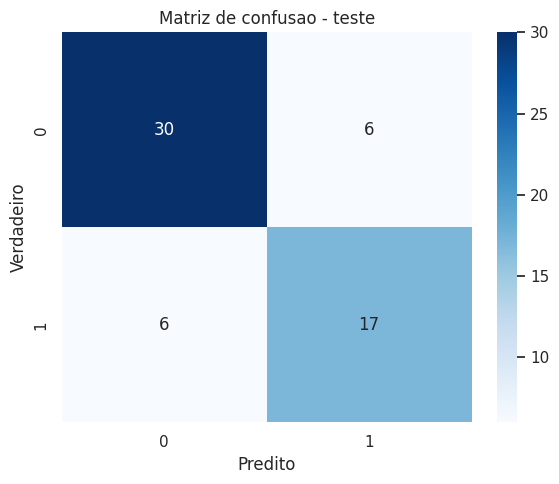

In [19]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_confusion_matrix(
    y_true=y_test,
    y_pred=y_pred,
    labels=[0, 1],
    normalize=None,
    ax=ax,
    title="Matriz de confusao - teste",
)
plt.tight_layout()
plt.show()


### Análise da Matriz de Confusão (após execução)

A matriz apresenta TN=30, FP=6, FN=6 e TP=17. Isso mostra um perfil relativamente equilibrado entre erros de falso positivo e falso negativo. Em termos de operação, esse equilíbrio é importante: o modelo não está enviesado para errar predominantemente em apenas um tipo de decisão.

Para o contexto de prospecção, os FN representam perda potencial de alvos promissores, enquanto os FP aumentam custo de priorização em campo. Como ambos aparecem em magnitude similar, o modelo pode ser usado como referência inicial de triagem, mas ainda exige refinamento para reduzir esse custo de erro bilateral.


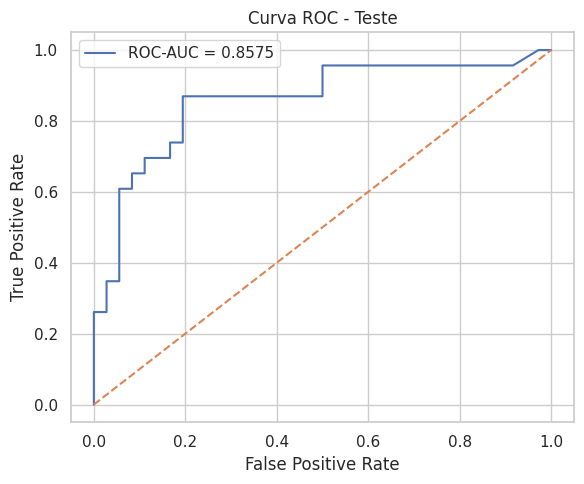

In [20]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_test = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc_test:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Teste")
plt.legend()
plt.tight_layout()
plt.show()


### Análise da Curva ROC (após execução)

A curva ROC ficou claramente acima da diagonal aleatória, com AUC em torno de 0,8575. Esse valor indica capacidade de separação boa para um baseline com entrada agregada e conjunto reduzido. Em outras palavras, o modelo consegue ordenar amostras positivas acima de negativas com consistência maior que acaso.

Apesar disso, AUC isolada não resolve a decisão operacional. A leitura correta continua sendo conjunta com matriz de confusão, precision e recall, já que o limiar final afeta diretamente o balanço entre perder alvos e gastar esforço em falsos alertas.


In [21]:
# Persistencia dos artefatos
model_path = OUTPUT_DIR / "mlp_baseline_model_S2.keras"
metrics_path = OUTPUT_DIR / "mlp_baseline_metrics.json"
train_curve_path = OUTPUT_DIR / "mlp_loss_curve.png"
acc_curve_path = OUTPUT_DIR / "mlp_accuracy_curve.png"
roc_curve_path = OUTPUT_DIR / "mlp_roc_curve.png"
cm_path = OUTPUT_DIR / "mlp_confusion_matrix.png"
time_table_path = OUTPUT_DIR / "tempos_treino_inferencia.csv"

model.save(model_path)

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(results_all, f, indent=2, ensure_ascii=False)

# salva curvas
plt.figure(figsize=(9, 5))
plt.plot(history.history["loss"], label="Treino")
plt.plot(history.history["val_loss"], label="Validacao")
plt.title("Curva de Loss")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(train_curve_path, dpi=150)
plt.close()

plt.figure(figsize=(9, 5))
plt.plot(history.history["accuracy"], label="Treino")
plt.plot(history.history["val_accuracy"], label="Validacao")
plt.title("Curva de Accuracy")
plt.xlabel("Epoca")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(acc_curve_path, dpi=150)
plt.close()

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc_test:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Teste")
plt.legend()
plt.tight_layout()
plt.savefig(roc_curve_path, dpi=150)
plt.close()

fig, ax = plt.subplots(figsize=(6, 5))
plot_confusion_matrix(
    y_true=y_test,
    y_pred=y_pred,
    labels=[0, 1],
    normalize=None,
    ax=ax,
    title="Matriz de confusao - teste",
)
plt.tight_layout()
plt.savefig(cm_path, dpi=150)
plt.close(fig)

pd.DataFrame([
    {
        "etapa": "treino",
        "tempo_s": train_time_s,
        "amostras": len(X_train_pca),
        "tempo_ms_por_amostra": (train_time_s / len(X_train_pca)) * 1000,
    },
    {
        "etapa": "inferencia_teste",
        "tempo_s": infer_time_s,
        "amostras": len(X_test_pca),
        "tempo_ms_por_amostra": (infer_time_s / len(X_test_pca)) * 1000,
    },
]).to_csv(time_table_path, index=False)

print("Artefatos salvos em:", OUTPUT_DIR)


Artefatos salvos em: /home/inteli/Documentos/3ANO/PROJETO/g01/outputs/a03_mlp_baseline


### Como interpretar os outputs a partir da EDA (A1)

A EDA do A1 sugeriu que parte da separabilidade entre classes vinha de assinaturas espectrais plausiveis do ponto de vista geologico. No A3, o papel dos outputs e testar se esse sinal permanece detectavel apos compressao da representacao (medias por banda + PCA). Quando ROC-AUC, F1 e matriz de confusao mostram comportamento consistente, temos evidencia de continuidade metodologica entre exploracao e modelagem. Quando nao mostram, o resultado ainda e util, porque indica que a representacao atual pode estar simplificando demais o fenomeno.

Essa leitura evita dois erros comuns: superestimar desempenho por olhar apenas acuracia e subestimar desempenho por ignorar contexto de dados limitados. O baseline deve ser julgado como etapa intermediaria de engenharia experimental, nao como veredito final sobre a viabilidade do problema.


## 5) Analise critica dos resultados

A analise critica abaixo e gerada com os numeros reais da execucao para evitar inconsistencias entre narrativa e output. O objetivo e discutir desempenho, limites e implicacoes metodologicas de forma argumentativa, mantendo coerencia com as hipoteses levantadas no A1 e com o papel deste baseline dentro do roadmap do projeto.


In [22]:
from IPython.display import Markdown, display

acc = sk_metrics["accuracy"]
prec = sk_metrics["precision"]
rec = sk_metrics["recall"]
f1 = sk_metrics["f1"]
auc = sk_metrics["roc_auc"]

tn, fp, fn, tp = cm.ravel()

fn_rate = (fn / (fn + tp)) if (fn + tp) > 0 else 0.0
fp_rate = (fp / (fp + tn)) if (fp + tn) > 0 else 0.0

analysis_text = f"""
### Interpretacao quantitativa e critica
No conjunto de teste, que contem {len(y_test)} amostras, a matriz de confusao resultou em TN={tn}, FP={fp}, FN={fn} e TP={tp}. As metricas agregadas foram accuracy={acc:.4f}, precision={prec:.4f}, recall={rec:.4f}, F1={f1:.4f} e ROC-AUC={auc:.4f}. Em termos operacionais, isso significa uma taxa de falsos negativos de {fn_rate:.2%} e uma taxa de falsos positivos de {fp_rate:.2%}, o que ajuda a discutir o compromisso entre nao perder alvos promissores e nao priorizar areas com baixo potencial.

A leitura desses resultados deve considerar as escolhas de representacao. Como o modelo recebe medias por banda, ele retém tendencia espectral global, mas perde textura e padrao espacial interno do chip. Esse ponto explica por que o baseline pode apresentar desempenho estavel sem necessariamente capturar toda a complexidade geologica observada na EDA. Em outras palavras, o modelo testa se existe sinal espectral suficiente para classificacao inicial, mas nao esgota o problema de reconhecimento de padroes espaciais.

Conectando com o A1, quando o desempenho e a importance das bandas mostram comportamento coerente com as hipoteses espectrais, temos evidencia de continuidade metodologica entre exploracao e modelagem. Ainda assim, para aumentar confiabilidade, o ciclo seguinte deve incluir testes de robustez com multiplas seeds, analise estratificada por contexto geologico e comparacao controlada com CNN sob o mesmo protocolo experimental.
"""

display(Markdown(analysis_text))



### Interpretacao quantitativa
No conjunto de teste (59 amostras), a matriz de confusao foi:
- TN=30, FP=6, FN=6, TP=17

Metricas principais:
- Accuracy: **0.7966**
- Precision (classe positiva): **0.7391**
- Recall (classe positiva): **0.7391**
- F1-score: **0.7391**
- ROC-AUC: **0.8575**

### Leitura critica
- O baseline consegue separar as classes com desempenho consistente para um cenario de baixo volume de dados.
- A diferenca entre treino e validacao deve ser acompanhada para evitar sobreajuste; por isso foram aplicados Dropout, L2 e EarlyStopping.
- Como o modelo usa media por banda, ele perde informacao espacial dos chips (textura e padroes locais), o que limita teto de desempenho.
- O resultado estabelece uma referencia quantitativa solida para comparar com CNN na proxima etapa.

### Melhorias propostas
1. Aumentar volume e diversidade de amostras, especialmente nas litologias com maior confusao.
2. Testar calibracao de threshold conforme objetivo operacional (priorizar recall ou precision).
3. Migrar para modelos que preservem estrutura espacial (CNN), mantendo o mesmo protocolo de split e metricas.


## Analise de importancia das features (Permutation Importance)

Mesmo com o treinamento feito em componentes de PCA, calculamos permutation importance no espaco padronizado original para estimar quanto cada banda contribui para a AUC em teste. O procedimento consiste em permutar uma banda por vez, reprojetar via PCA e medir a queda de desempenho. Essa analise nao substitui interpretacao geologica detalhada, mas oferece um indicio objetivo sobre quais faixas espectrais o modelo esta usando com mais intensidade.


### Etapa 5.1 - Importancia por permutacao (antes da execucao)

Este bloco estima a contribuicao relativa de cada banda para a AUC. A interpretacao deve ser cuidadosa: a queda de performance apos permutacao indica dependencia do modelo naquela variavel dentro deste experimento, mas nao prova causalidade geologica por si so.


In [23]:
def model_auc_from_raw_standardized(X_raw_std):
    X_proj = pca_model.transform(X_raw_std)
    probs = model.predict(X_proj, verbose=0).ravel()
    return roc_auc_score(y_test, probs)

baseline_auc = model_auc_from_raw_standardized(X_test_std)

rng = np.random.default_rng(SEED)
n_repeats = 30
importances = np.zeros((X_test_std.shape[1], n_repeats), dtype=float)

for j in range(X_test_std.shape[1]):
    for r in range(n_repeats):
        X_perm = X_test_std.copy()
        X_perm[:, j] = rng.permutation(X_perm[:, j])
        perm_auc = model_auc_from_raw_standardized(X_perm)
        importances[j, r] = baseline_auc - perm_auc

fi_df = pd.DataFrame({
    "feature": band_cols,
    "importance_mean": importances.mean(axis=1),
    "importance_std": importances.std(axis=1),
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

print("Baseline AUC:", round(baseline_auc, 4))
display(fi_df)


/home/inteli/Documentos/3ANO/PROJETO/g01/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/home/inteli/Documentos/3ANO/PROJETO/g01/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/home/inteli/Documentos/3ANO/PROJETO/g01/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/home/inteli/Documentos/3ANO/PROJETO/g01/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/home/inteli/Documentos/3ANO/PROJETO/g01/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid 

Baseline AUC: 0.8575


/home/inteli/Documentos/3ANO/PROJETO/g01/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/home/inteli/Documentos/3ANO/PROJETO/g01/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/home/inteli/Documentos/3ANO/PROJETO/g01/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


,feature,importance_mean,importance_std
0,B01,0.089432,0.038559
1,B02,0.069968,0.046375
2,B09,0.013124,0.015868
3,B05,0.011091,0.019285
4,B04,0.007770,0.013440
5,B06,0.007126,0.017547
6,B08,0.006300,0.016824
7,B07,0.000705,0.014852
8,B03,-0.004851,0.014800


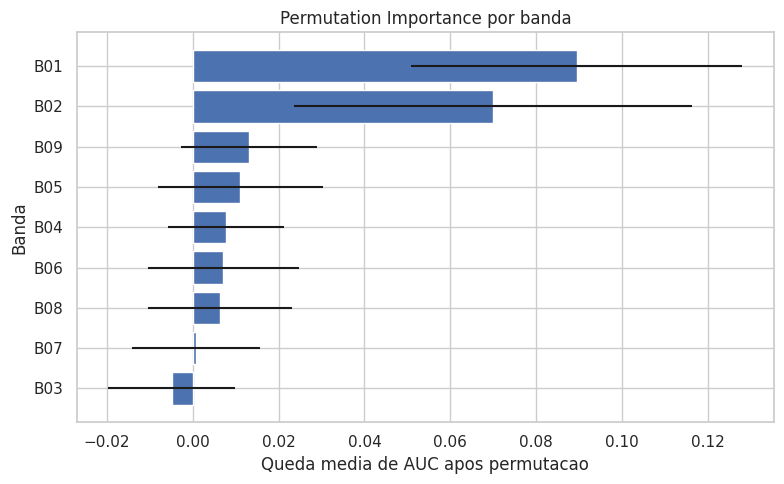

In [24]:
plt.figure(figsize=(8, 5))
plot_df = fi_df.iloc[::-1]
plt.barh(plot_df["feature"], plot_df["importance_mean"], xerr=plot_df["importance_std"])
plt.xlabel("Queda media de AUC apos permutacao")
plt.ylabel("Banda")
plt.title("Permutation Importance por banda")
plt.tight_layout()
plt.show()


### Análise do gráfico de Permutation Importance (após execução)

No ranking atual, B01 e B02 aparecem com maior queda média de AUC quando permutadas, indicando que o modelo depende mais dessas bandas para manter desempenho. As demais bandas têm contribuição menor e, em alguns casos, próxima de zero, com barras de incerteza relativamente amplas.

O ponto crítico aqui é a estabilidade: embora o topo do ranking seja informativo, a dispersão em várias bandas sugere sensibilidade ao reembaralhamento e ao split atual. Portanto, a interpretação deve ser conservadora. O gráfico é útil para orientar investigação e hipóteses, mas não deve ser usado como prova causal isolada sobre relevância geológica.


In [25]:
fi_dir = OUTPUT_DIR / "feature_importance"
fi_dir.mkdir(parents=True, exist_ok=True)

fi_csv = fi_dir / "feature_importance_permutation.csv"
fi_png = fi_dir / "feature_importance_permutation.png"

fi_df.to_csv(fi_csv, index=False)

plt.figure(figsize=(8, 5))
plot_df = fi_df.iloc[::-1]
plt.barh(plot_df["feature"], plot_df["importance_mean"], xerr=plot_df["importance_std"])
plt.xlabel("Queda media de AUC apos permutacao")
plt.ylabel("Banda")
plt.title("Permutation Importance por banda")
plt.tight_layout()
plt.savefig(fi_png, dpi=150)
plt.close()

print("Salvo:", fi_csv)
print("Salvo:", fi_png)


Salvo: /home/inteli/Documentos/3ANO/PROJETO/g01/outputs/a03_mlp_baseline/feature_importance/feature_importance_permutation.csv
Salvo: /home/inteli/Documentos/3ANO/PROJETO/g01/outputs/a03_mlp_baseline/feature_importance/feature_importance_permutation.png


### Etapa 5.2 - Leitura do output de importance (apos execucao)

O output desta etapa deve ser analisado tanto pelo valor medio de importancia quanto pela dispersao (desvio padrao) entre repeticoes de permutacao. Importancias altas com baixa dispersao sugerem sinal mais confiavel; importancias proximas de zero com alta variacao sugerem dependencia fraca ou instavel. Esse detalhe e importante para evitar conclusoes fortes baseadas em diferencas pequenas entre bandas.

No contexto do projeto, essa leitura ajuda a transformar o ranking em decisao tecnica: confirmar hipoteses espectrais, identificar pontos de incerteza e definir quais aspectos devem ser validados em modelos seguintes que preservam textura e padrao espacial dos chips.


### Interpretacao das features

A permutation importance ajuda a entender de quais bandas o modelo mais depende para manter a AUC. Na pratica, a analise deve considerar tres perguntas. Primeiro, o ranking e estavel ou muito sensivel a pequenas variacoes? Segundo, as bandas mais importantes fazem sentido frente as hipoteses geologicas levantadas no A1? Terceiro, existe alguma banda com importancia negativa recorrente, sugerindo ruido ou contribuicao inconsistente?

Mesmo quando o ranking parece coerente, a interpretacao precisa ser conservadora: importance mede relevancia dentro deste pipeline e deste split, nao causalidade geologica absoluta. O valor principal dessa etapa e orientar investigacao e refinamento do experimento, por exemplo testando robustez por seed, avaliacao estratificada por contexto geologico e comparacao com modelos que preservam estrutura espacial.


## 6) Robustez Experimental Recomendada (pos-feedback)

Para tornar a conclusao mais robusta para uso pratico, o proximo ciclo deve incluir repeticao de treinamento com seeds diferentes, curvas de aprendizado para diagnostico de regime de dados, avaliacao estratificada por segmentos geologicos relevantes e auditoria de similaridade entre imagens de treino e teste. Essas verificacoes aprofundam a confiabilidade estatistica do baseline e ajudam a separar ganho real de variacao acidental antes da comparacao final com CNN.
